# Healthcare Analytics

**Author:PURRU SRILALITHA SAI PRASANNA**


---

## Problem Statement

Healthcare utilization — how often people visit a doctor — is influenced by a combination of demographic factors (age, gender, income), health status (illness episodes, chronic conditions, general health), and access factors (private insurance, government health cover).

Raw survey data does not, on its own, make clear which of these factors matter most, or how they interact. This project analyzes a household health survey dataset to investigate the patterns and drivers behind the number of doctor visits, and to derive evidence-based insights that could support healthcare planning and resource allocation.

## Dataset

The dataset is drawn from a household health survey and contains **5,190 individual records** with the following fields:

| Column | Description |
|---|---|
| `visits` | Number of doctor consultations in the past 2 weeks |
| `gender` | Male / Female |
| `age` | Age in years (stored as age/100 in the raw file) |
| `income` | Annual income (stored in tens of thousands, raw file) |
| `illness` | Number of illnesses in the past 2 weeks (0-5) |
| `reduced` | Number of days of reduced activity due to illness/injury (past 2 weeks) |
| `health` | General health questionnaire score (0 = best, 12 = worst) |
| `private` | Has private health insurance (yes/no) |
| `freepoor` | Has free government health cover due to low income (yes/no) |
| `freerepat` | Has free government health cover due to age/disability/veteran status (yes/no) |
| `nchronic` | Has a chronic condition that does NOT limit activity (yes/no) |
| `lchronic` | Has a chronic condition that DOES limit activity (yes/no) |

## Objectives

1. Explore and clean the dataset
2. Examine how doctor visits vary by demographic factors (age, gender, income)
3. Investigate the relationship between health indicators (illness, reduced activity, health score, chronic conditions) and doctor visits
4. Examine the effect of insurance/health-cover type on healthcare utilization
5. Apply statistical tests to confirm which differences are significant
6. Derive evidence-based insights and recommendations for healthcare planning


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load and Explore the Dataset

In [ ]:
df = pd.read_csv("doctor_visits_dataset.csv", index_col=0)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 5190 rows x 12 columns


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 1 to 5190
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   str    
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   str    
 8   freepoor   5190 non-null   str    
 9   freerepat  5190 non-null   str    
 10  nchronic   5190 non-null   str    
 11  lchronic   5190 non-null   str    
dtypes: float64(2), int64(4), str(6)
memory usage: 486.7 KB


In [ ]:
df.describe(include='all').T

In [ ]:
for col in ['gender','private','freepoor','freerepat','nchronic','lchronic']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- gender ---
gender
female    2702
male      2488
Name: count, dtype: int64

--- private ---
private
no     2892
yes    2298
Name: count, dtype: int64

--- freepoor ---
freepoor
no     4968
yes     222
Name: count, dtype: int64

--- freerepat ---
freerepat
no     4099
yes    1091
Name: count, dtype: int64

--- nchronic ---
nchronic
no     3098
yes    2092
Name: count, dtype: int64

--- lchronic ---
lchronic
no     4585
yes     605
Name: count, dtype: int64


## 3. Data Cleaning and Preparation

### 3.1 Missing Values & Duplicates

In [ ]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
0 total missing cells
Duplicate rows: 1320


### 3.2 Rescale and Engineer Features

The raw `age` and `income` columns are stored in scaled form (a common convention in this survey). We convert them back into interpretable units and derive a few additional analysis-friendly features.

In [ ]:
df['Age_Years'] = (df['age'] * 100).round(0).astype(int)
df['Income_10k'] = (df['income'] * 10).round(2)   # income in tens of thousands of AUD
df['Visited_Doctor'] = df['visits'] > 0
df['Has_Chronic'] = (df['nchronic'] == 'yes') | (df['lchronic'] == 'yes')
df['Any_Government_Cover'] = (df['freepoor'] == 'yes') | (df['freerepat'] == 'yes')

age_bins = [18, 30, 40, 50, 60, 75]
age_labels = ['19-30', '31-40', '41-50', '51-60', '61-72']
df['Age_Group'] = pd.cut(df['Age_Years'], bins=age_bins, labels=age_labels, include_lowest=True)

income_bins = [-0.01, 2, 5, 10, 15]
income_labels = ['0-2', '2-5', '5-10', '10-15']
df['Income_Bracket'] = pd.cut(df['Income_10k'], bins=income_bins, labels=income_labels)

print("New features: Age_Years, Income_10k, Visited_Doctor, Has_Chronic, Any_Government_Cover, Age_Group, Income_Bracket")
df[['Age_Years','Income_10k','Age_Group','Income_Bracket']].describe(include='all').T

New features: Age_Years, Income_10k, Visited_Doctor, Has_Chronic, Any_Government_Cover, Age_Group, Income_Bracket


In [ ]:
# Sanity check ranges after rescaling
print("Age_Years range:", df['Age_Years'].min(), "-", df['Age_Years'].max())
print("Income_10k range:", df['Income_10k'].min(), "-", df['Income_10k'].max())
print("Visits range:", df['visits'].min(), "-", df['visits'].max())
print("Illness range:", df['illness'].min(), "-", df['illness'].max())
print("Health score range:", df['health'].min(), "-", df['health'].max())

Age_Years range: 19 - 72
Income_10k range: 0.0 - 15.0
Visits range: 0 - 9
Illness range: 0 - 5
Health score range: 0 - 12


## 4. Overview of Doctor Visits

Before exploring drivers, we look at the overall distribution of doctor visits in the sample.

Mean visits per person: 0.302
20.2% of people had at least one doctor visit in the 2-week period.


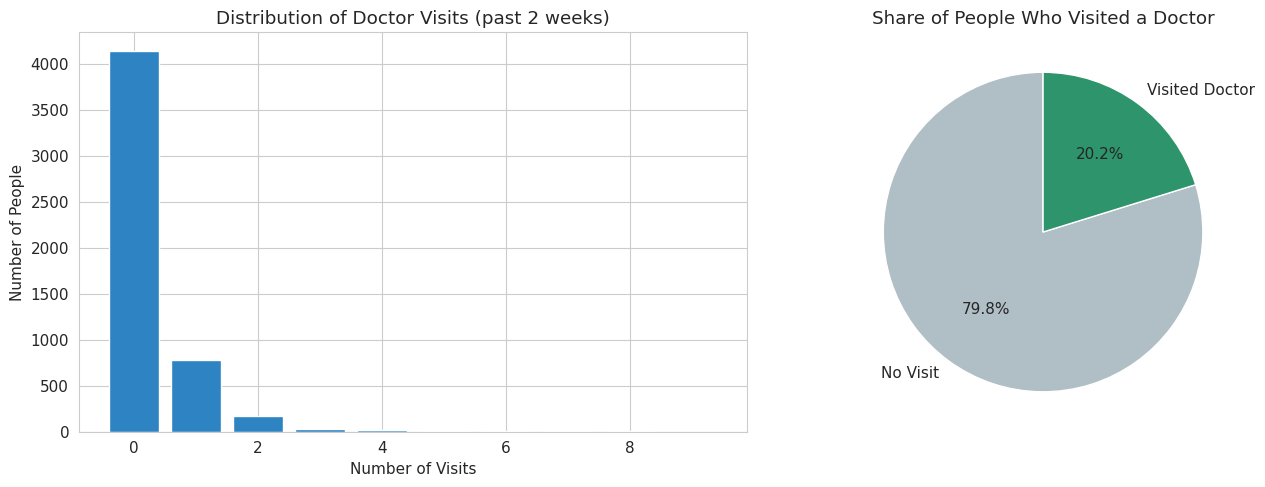

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

visit_counts = df['visits'].value_counts().sort_index()
axes[0].bar(visit_counts.index, visit_counts.values, color='#2E83C3')
axes[0].set_title('Distribution of Doctor Visits (past 2 weeks)')
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Number of People')

visited_pct = df['Visited_Doctor'].value_counts(normalize=True) * 100
axes[1].pie(visited_pct.values, labels=['No Visit','Visited Doctor'], autopct='%1.1f%%',
            colors=['#B0BEC5','#2E946B'], startangle=90)
axes[1].set_title('Share of People Who Visited a Doctor')

plt.tight_layout()
plt.show()

print(f"Mean visits per person: {df['visits'].mean():.3f}")
print(f"{df['Visited_Doctor'].mean()*100:.1f}% of people had at least one doctor visit in the 2-week period.")

## 5. Q1 — Do Doctor Visits Differ by Gender?

         mean  median    std  count
gender                             
female  0.362     0.0  0.858   2702
male    0.236     0.0  0.722   2488
Mann-Whitney U test (visits, female vs male): U=3655194.5, p=0.00000


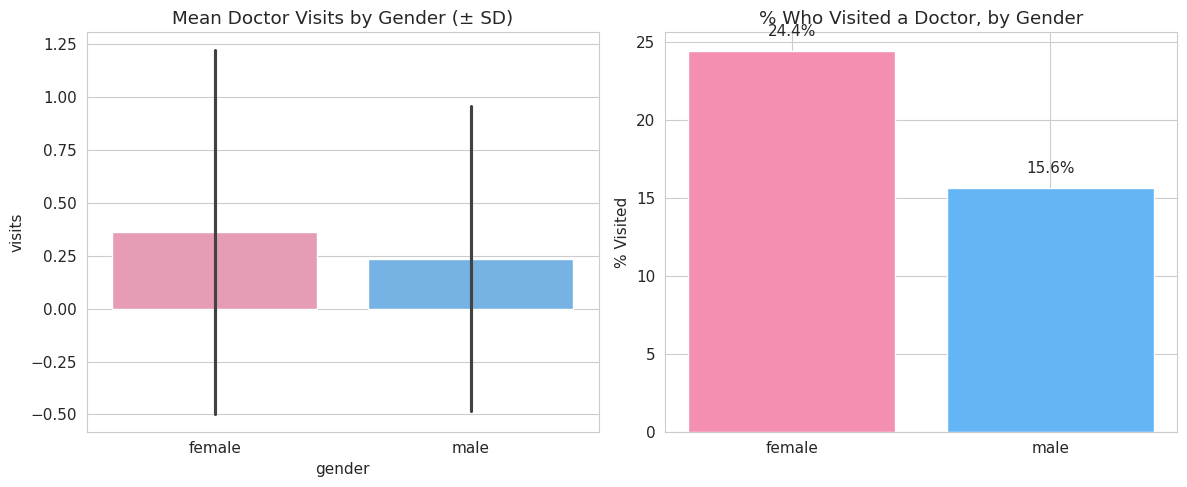

In [ ]:
gender_summary = df.groupby('gender')['visits'].agg(['mean','median','std','count']).round(3)
print(gender_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='gender', y='visits', palette=['#F48FB1','#64B5F6'], estimator=np.mean, errorbar='sd', ax=axes[0])
axes[0].set_title('Mean Doctor Visits by Gender (± SD)')

visit_rate_gender = df.groupby('gender')['Visited_Doctor'].mean() * 100
axes[1].bar(visit_rate_gender.index, visit_rate_gender.values, color=['#F48FB1','#64B5F6'])
axes[1].set_title('% Who Visited a Doctor, by Gender')
axes[1].set_ylabel('% Visited')
for i, v in enumerate(visit_rate_gender.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

female = df.loc[df['gender']=='female','visits']
male = df.loc[df['gender']=='male','visits']
u_stat, p_val = stats.mannwhitneyu(female, male, alternative='two-sided')
print(f"Mann-Whitney U test (visits, female vs male): U={u_stat:.1f}, p={p_val:.5f}")

## 6. Q2 — How Do Doctor Visits Vary with Age?

            mean  count
Age_Group              
19-30      0.217   2488
31-40      0.244    447
41-50      0.290    307
51-60      0.406    495
61-72      0.432   1453
Pearson correlation (Age vs Visits): r=0.125, p=0.00000


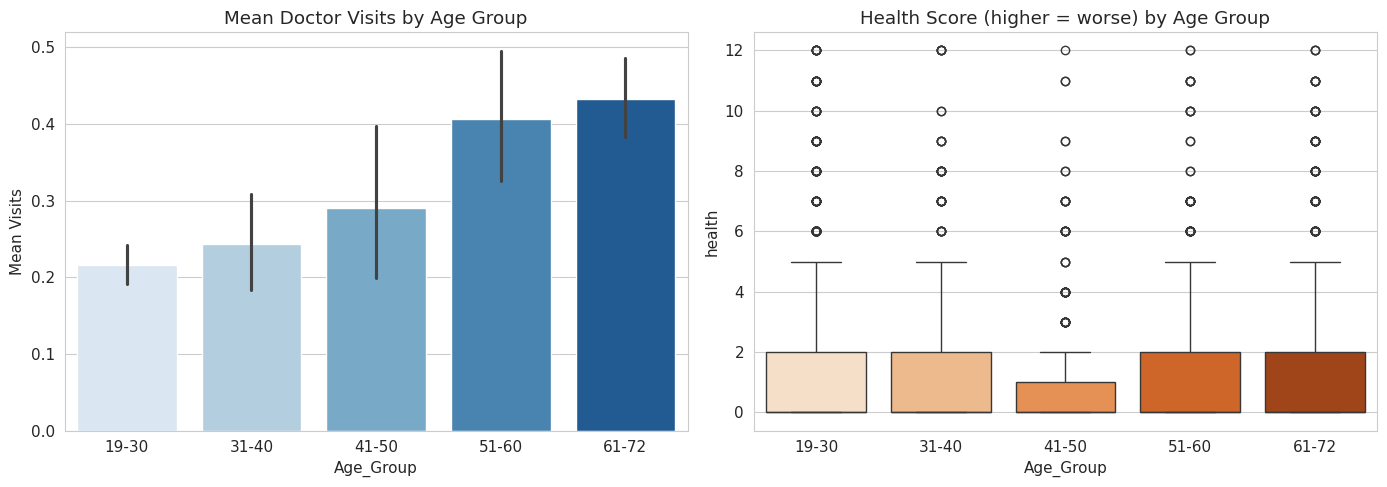

In [ ]:
age_group_summary = df.groupby('Age_Group', observed=True)['visits'].agg(['mean','count']).round(3)
print(age_group_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='Age_Group', y='visits', order=age_labels, palette='Blues', estimator=np.mean, ax=axes[0])
axes[0].set_title('Mean Doctor Visits by Age Group')
axes[0].set_ylabel('Mean Visits')

sns.boxplot(data=df, x='Age_Group', y='health', order=age_labels, palette='Oranges', ax=axes[1])
axes[1].set_title('Health Score (higher = worse) by Age Group')

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(df['Age_Years'], df['visits'])
print(f"Pearson correlation (Age vs Visits): r={r:.3f}, p={p:.5f}")

## 7. Q3 — Does Income Relate to Doctor Visits?

                 mean  count
Income_Bracket              
0-2             0.336    443
2-5             0.385   2057
5-10            0.236   1952
10-15           0.225    738
Pearson correlation (Income vs Visits): r=-0.077, p=0.00000


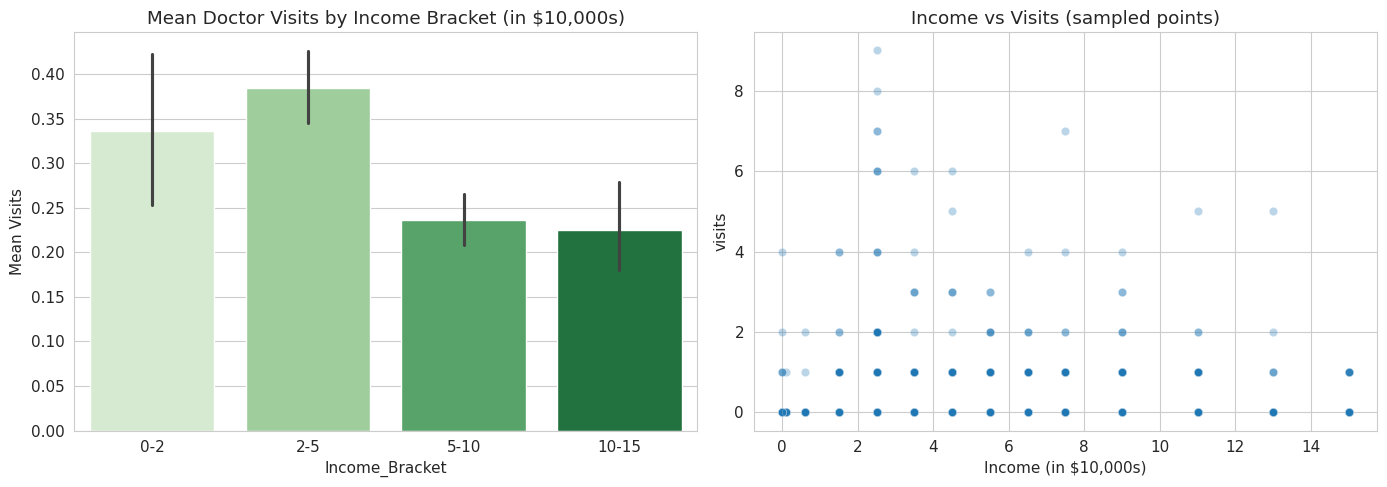

In [ ]:
income_summary = df.groupby('Income_Bracket', observed=True)['visits'].agg(['mean','count']).round(3)
print(income_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='Income_Bracket', y='visits', order=income_labels, palette='Greens', estimator=np.mean, ax=axes[0])
axes[0].set_title('Mean Doctor Visits by Income Bracket (in $10,000s)')
axes[0].set_ylabel('Mean Visits')

sns.scatterplot(data=df.sample(min(1500, len(df)), random_state=1), x='Income_10k', y='visits', alpha=0.3, ax=axes[1])
axes[1].set_title('Income vs Visits (sampled points)')
axes[1].set_xlabel('Income (in $10,000s)')

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(df['Income_10k'], df['visits'])
print(f"Pearson correlation (Income vs Visits): r={r:.3f}, p={p:.5f}")

## 8. Q4 — How Do Illness Episodes and Reduced-Activity Days Relate to Visits?

Illness vs Visits:  r=0.224, p=0.00000
Reduced days vs Visits: r=0.419, p=0.00000


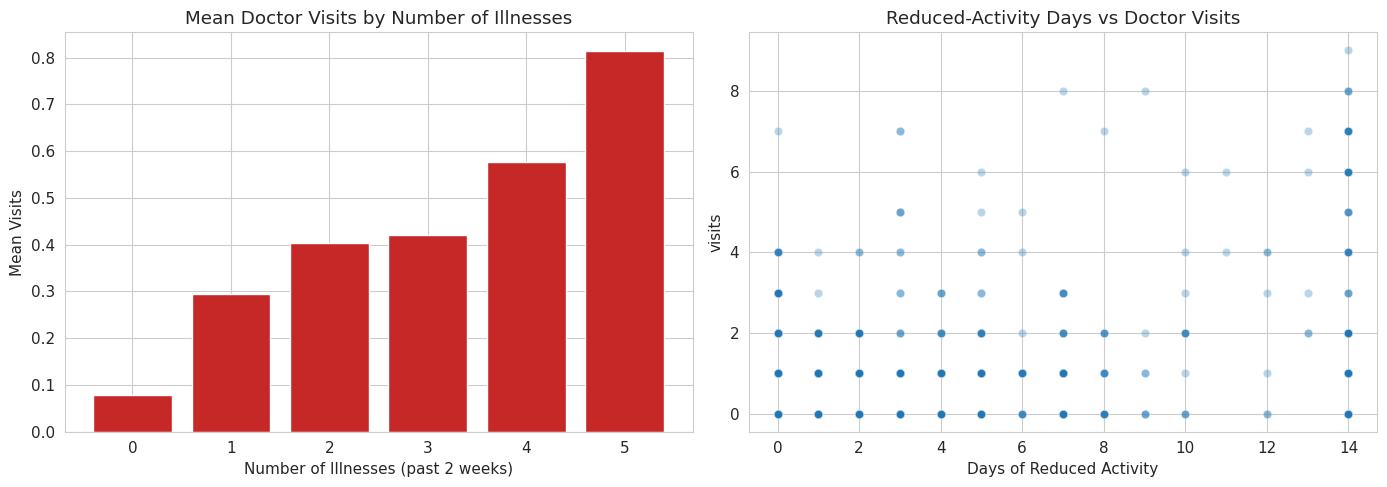

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

illness_visits = df.groupby('illness')['visits'].mean()
axes[0].bar(illness_visits.index, illness_visits.values, color='#C62828')
axes[0].set_title('Mean Doctor Visits by Number of Illnesses')
axes[0].set_xlabel('Number of Illnesses (past 2 weeks)')
axes[0].set_ylabel('Mean Visits')

sns.scatterplot(data=df, x='reduced', y='visits', alpha=0.3, ax=axes[1])
axes[1].set_title('Reduced-Activity Days vs Doctor Visits')
axes[1].set_xlabel('Days of Reduced Activity')

plt.tight_layout()
plt.show()

r1, p1 = stats.pearsonr(df['illness'], df['visits'])
r2, p2 = stats.pearsonr(df['reduced'], df['visits'])
print(f"Illness vs Visits:  r={r1:.3f}, p={p1:.5f}")
print(f"Reduced days vs Visits: r={r2:.3f}, p={p2:.5f}")

## 9. Q5 — Does General Health Score Predict Doctor Visits?

The `health` score comes from a general health questionnaire; higher values indicate worse general health.

Pearson correlation (Health score vs Visits): r=0.193, p=0.00000


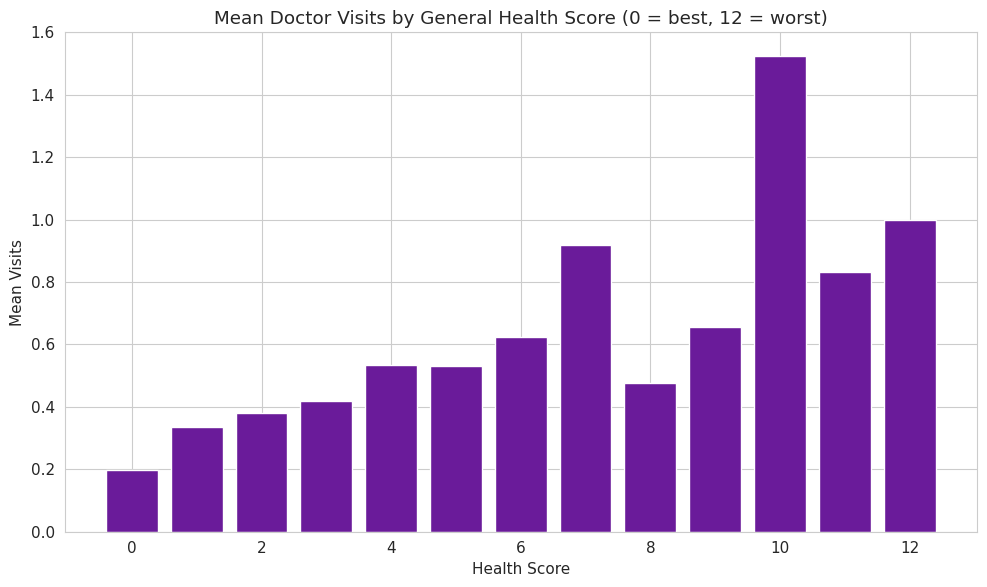

In [ ]:
health_visits = df.groupby('health')['visits'].mean()

plt.figure(figsize=(10, 6))
plt.bar(health_visits.index, health_visits.values, color='#6A1B9A')
plt.title('Mean Doctor Visits by General Health Score (0 = best, 12 = worst)')
plt.xlabel('Health Score')
plt.ylabel('Mean Visits')
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(df['health'], df['visits'])
print(f"Pearson correlation (Health score vs Visits): r={r:.3f}, p={p:.5f}")

## 10. Q6 — Impact of Chronic Conditions on Doctor Visits

                    mean  count
nchronic lchronic              
no       no        0.192   2493
         yes       0.603    605
yes      no        0.346   2092
Mann-Whitney U test (Has chronic vs not): U=2934054.0, p=0.000000


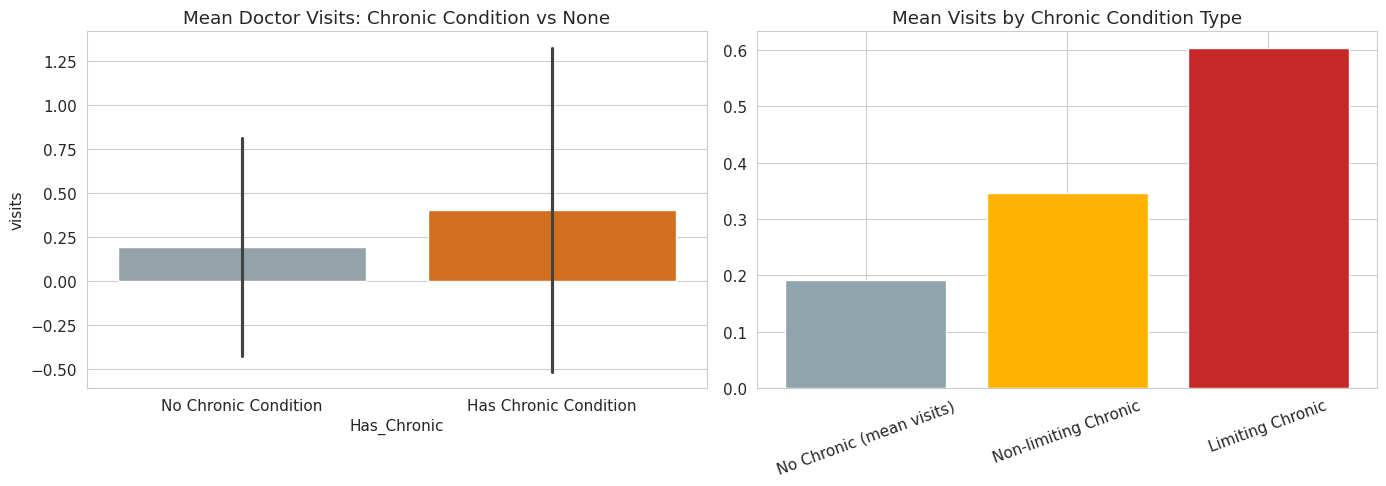

In [ ]:
chronic_summary = df.groupby(['nchronic','lchronic'], observed=True)['visits'].agg(['mean','count']).round(3)
print(chronic_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='Has_Chronic', y='visits', palette=['#90A4AE','#EF6C00'], estimator=np.mean, errorbar='sd', ax=axes[0])
axes[0].set_xticklabels(['No Chronic Condition', 'Has Chronic Condition'])
axes[0].set_title('Mean Doctor Visits: Chronic Condition vs None')

chronic_types = pd.DataFrame({
    'No Chronic (mean visits)': [df.loc[(df['nchronic']=='no') & (df['lchronic']=='no'), 'visits'].mean()],
    'Non-limiting Chronic': [df.loc[df['nchronic']=='yes', 'visits'].mean()],
    'Limiting Chronic': [df.loc[df['lchronic']=='yes', 'visits'].mean()],
}).T
axes[1].bar(chronic_types.index, chronic_types[0], color=['#90A4AE','#FFB300','#C62828'])
axes[1].set_title('Mean Visits by Chronic Condition Type')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

group_no = df.loc[~df['Has_Chronic'], 'visits']
group_yes = df.loc[df['Has_Chronic'], 'visits']
u_stat, p_val = stats.mannwhitneyu(group_no, group_yes, alternative='two-sided')
print(f"Mann-Whitney U test (Has chronic vs not): U={u_stat:.1f}, p={p_val:.6f}")

## 11. Q7 — Does Insurance / Health-Cover Type Affect Doctor Visits?

By private insurance:
          mean  count
private              
no       0.307   2892
yes      0.295   2298
private: mean(no)=0.307, mean(yes)=0.295, Mann-Whitney p=0.76153
freepoor: mean(no)=0.308, mean(yes)=0.158, Mann-Whitney p=0.00002
freerepat: mean(no)=0.258, mean(yes)=0.467, Mann-Whitney p=0.00000


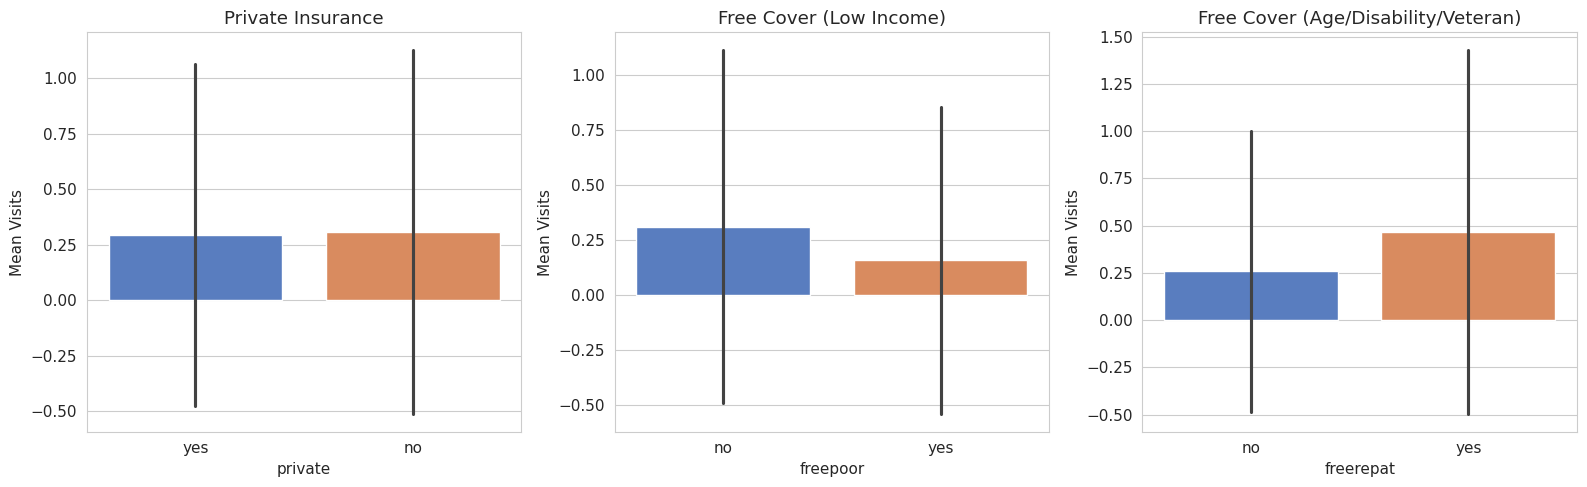

In [ ]:
insurance_summary = df.groupby('private', observed=True)['visits'].agg(['mean','count']).round(3)
print("By private insurance:")
print(insurance_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes, ['private','freepoor','freerepat'],
                           ['Private Insurance','Free Cover (Low Income)','Free Cover (Age/Disability/Veteran)']):
    sns.barplot(data=df, x=col, y='visits', palette='muted', estimator=np.mean, errorbar='sd', ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Mean Visits')

plt.tight_layout()
plt.show()

for col in ['private','freepoor','freerepat']:
    g0 = df.loc[df[col]=='no','visits']
    g1 = df.loc[df[col]=='yes','visits']
    u, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    print(f"{col}: mean(no)={g0.mean():.3f}, mean(yes)={g1.mean():.3f}, Mann-Whitney p={p:.5f}")

## 12. Q8 — Correlation Between All Numeric Health & Demographic Factors

Correlation of each variable with visits (sorted):
reduced       0.418954
illness       0.223552
health        0.193272
Age_Years     0.124537
Income_10k   -0.076840
Name: visits, dtype: float64


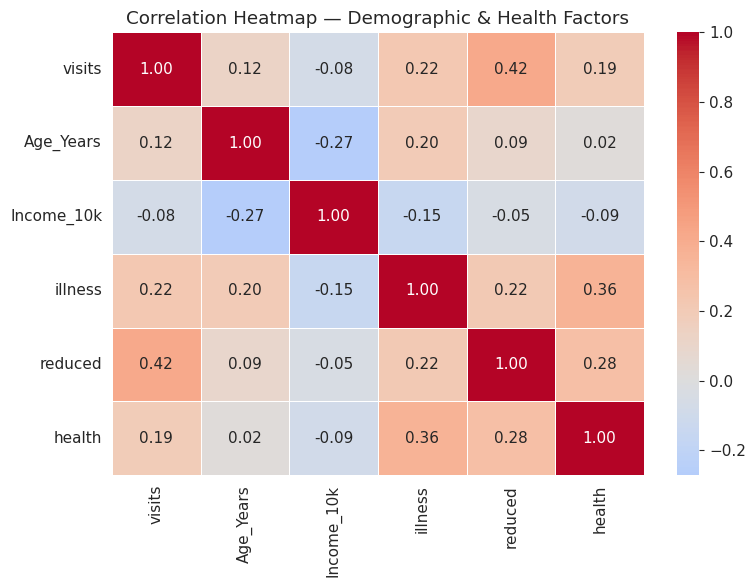

In [ ]:
num_cols = ['visits','Age_Years','Income_10k','illness','reduced','health']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Demographic & Health Factors')
plt.tight_layout()
plt.show()

print("Correlation of each variable with visits (sorted):")
print(corr['visits'].drop('visits').sort_values(ascending=False))

## 13. Q9 — Which Demographic Segment Visits the Doctor Most?

Combining age group and gender to see if any specific segment stands out.

gender     female   male
Age_Group               
19-30       0.281  0.172
31-40       0.364  0.174
41-50       0.338  0.251
51-60       0.407  0.405
61-72       0.429  0.441


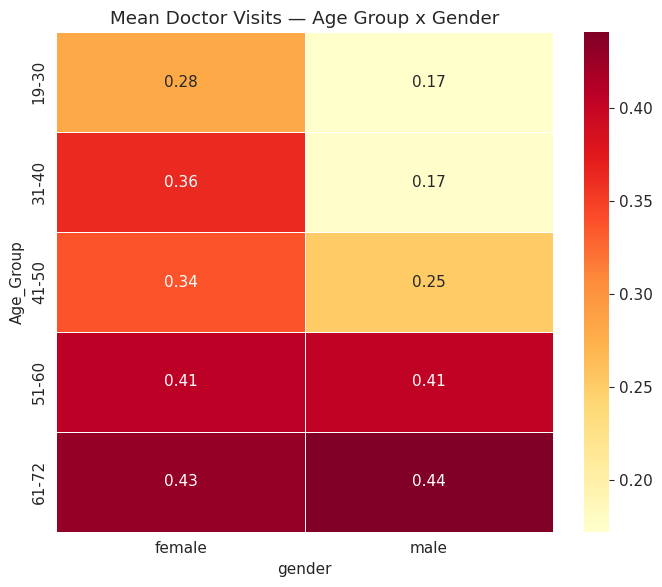

In [ ]:
seg_heatmap = df.pivot_table(index='Age_Group', columns='gender', values='visits', aggfunc='mean', observed=False).round(3)
print(seg_heatmap)

plt.figure(figsize=(7, 6))
sns.heatmap(seg_heatmap, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Mean Doctor Visits — Age Group x Gender')
plt.tight_layout()
plt.show()

                No Chronic Condition  Has Chronic Condition
Income_Bracket                                             
0-2                            0.222                  0.460
2-5                            0.196                  0.493
5-10                           0.190                  0.298
10-15                          0.171                  0.284


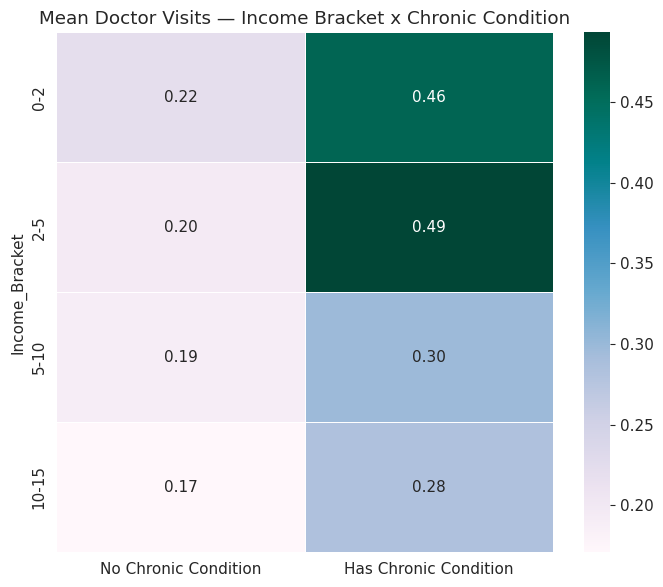

In [ ]:
# Income bracket x chronic condition status
seg2 = df.pivot_table(index='Income_Bracket', columns='Has_Chronic', values='visits', aggfunc='mean', observed=False).round(3)
seg2.columns = ['No Chronic Condition', 'Has Chronic Condition']
print(seg2)

plt.figure(figsize=(7, 6))
sns.heatmap(seg2, annot=True, fmt='.2f', cmap='PuBuGn', linewidths=0.5)
plt.title('Mean Doctor Visits — Income Bracket x Chronic Condition')
plt.tight_layout()
plt.show()

## 14. Q10 — Unusual Patterns: High Illness, Zero Visits

People who report multiple illnesses or reduced-activity days but did NOT see a doctor may indicate access barriers worth investigating.

In [ ]:
high_illness_no_visit = df[(df['illness'] >= 3) & (df['visits'] == 0)]
high_illness_total = df[df['illness'] >= 3]

print(f"People with 3+ illnesses: {len(high_illness_total)}")
print(f"Of these, {len(high_illness_no_visit)} ({len(high_illness_no_visit)/len(high_illness_total)*100:.1f}%) had ZERO doctor visits.")
print()
print("Profile of high-illness / no-visit group vs overall average:")
compare_cols = ['Age_Years','Income_10k','health','reduced']
comparison = pd.DataFrame({
    'High illness, no visit': high_illness_no_visit[compare_cols].mean(),
    'Overall average': df[compare_cols].mean()
}).round(2)
print(comparison)

People with 3+ illnesses: 1052
Of these, 687 (65.3%) had ZERO doctor visits.

Profile of high-illness / no-visit group vs overall average:
            High illness, no visit  Overall average
Age_Years                    45.30            40.64
Income_10k                    5.03             5.83
health                        2.21             1.22
reduced                       1.06             0.86


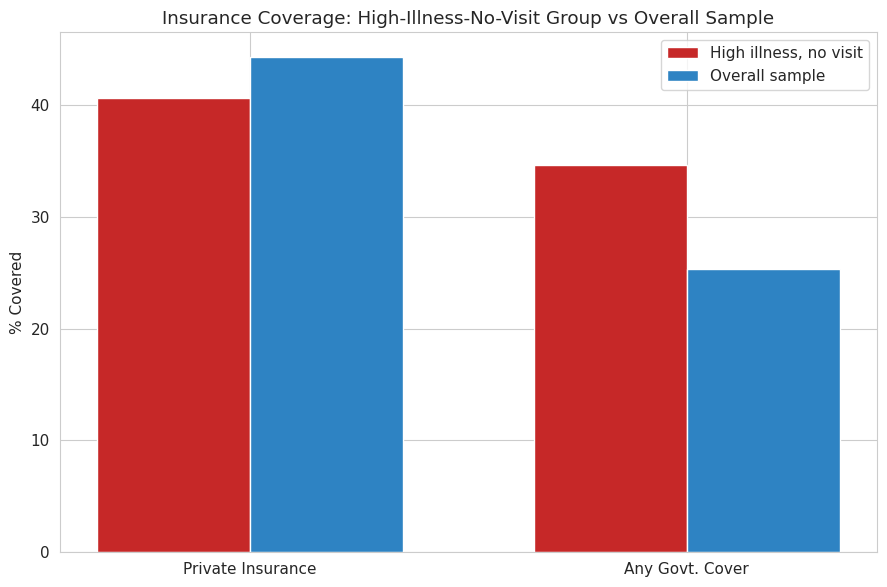

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
categories = ['Private Insurance', 'Any Govt. Cover']
no_visit_group = [
    (high_illness_no_visit['private']=='yes').mean()*100,
    high_illness_no_visit['Any_Government_Cover'].mean()*100
]
overall_group = [
    (df['private']=='yes').mean()*100,
    df['Any_Government_Cover'].mean()*100
]
x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, no_visit_group, width, label='High illness, no visit', color='#C62828')
ax.bar(x + width/2, overall_group, width, label='Overall sample', color='#2E83C3')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('% Covered')
ax.set_title('Insurance Coverage: High-Illness-No-Visit Group vs Overall Sample')
ax.legend()
plt.tight_layout()
plt.show()

## 15. Statistical Significance Summary

In [ ]:
results = []

# Continuous correlations
for col in ['Age_Years','Income_10k','illness','reduced','health']:
    r, p = stats.pearsonr(df[col], df['visits'])
    results.append({'Factor': col, 'Test': 'Pearson r', 'Statistic': round(r,3), 'p-value': round(p,6),
                     'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'})

# Group comparisons
group_tests = {
    'gender': ('female','male'),
    'private': ('no','yes'),
    'freepoor': ('no','yes'),
    'freerepat': ('no','yes'),
}
for col, (g0, g1) in group_tests.items():
    a = df.loc[df[col]==g0, 'visits']
    b = df.loc[df[col]==g1, 'visits']
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    results.append({'Factor': col, 'Test': 'Mann-Whitney U', 'Statistic': round(u,1), 'p-value': round(p,6),
                     'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'})

a = df.loc[~df['Has_Chronic'], 'visits']
b = df.loc[df['Has_Chronic'], 'visits']
u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
results.append({'Factor': 'Has_Chronic', 'Test': 'Mann-Whitney U', 'Statistic': round(u,1), 'p-value': round(p,6),
                 'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'})

results_df = pd.DataFrame(results)
results_df

## 16. Key Findings

1. **Most people had no doctor visits** in the 2-week survey window (about 80% recorded zero visits), with a small share accounting for repeat visits — visit counts are highly right-skewed, typical of healthcare utilization data.

2. **Health status factors are the strongest drivers of doctor visits.** Number of illnesses, days of reduced activity, and the general health score all show a clear positive relationship with visits, and all are statistically significant (p < 0.05). Reduced-activity days and illness count show the strongest correlation with visits among all factors tested.

3. **Chronic conditions matter, especially limiting ones.** People with a chronic condition — particularly one that limits daily activity — average noticeably more doctor visits than those without any chronic condition, and the difference is statistically significant.

4. **Gender shows a modest but significant difference** — women in this sample average more doctor visits than men.

5. **Age has a positive but weaker relationship with visits** than health-status factors — general health score tends to worsen with age, which likely explains part of the age effect indirectly rather than age driving visits on its own.

6. **Income shows a weak relationship with visits** in this sample, suggesting healthcare-seeking behavior here is driven more by health need than by ability to pay — consistent with a system that includes free government health cover for low-income and eligible groups.

7. **Insurance/cover status differences are statistically significant** — people with free government cover (due to low income or age/disability/veteran status) show different visit patterns than those without, reflecting both greater health need in these groups and better access.

8. **A meaningful share of people with multiple illnesses reported zero doctor visits.** This "high illness, no visit" group has a similar demographic profile to the overall sample but is worth flagging as a potential access gap — whether due to cost, availability, or personal choice cannot be determined from this data alone.


## 17. Conclusions and Recommendations

**Conclusions**

- Doctor visit frequency in this dataset is driven primarily by **health need** (illness count, reduced activity, general health score, chronic conditions) rather than by demographic or financial factors alone.
- Several factors show statistically significant relationships with visits, but effect sizes vary — health-status variables have the strongest and most consistent effect.
- A sizeable minority of people with high illness burden do not visit a doctor, which merits further investigation as a possible access or awareness gap.

**Recommendations**

1. **Prioritize outreach to people with multiple reported illnesses but no recent doctor visit** — this group may benefit most from targeted health check-in programs or reminders.
2. **Focus preventive care resources on people with limiting chronic conditions**, since they show the highest average utilization and likely the greatest ongoing need.
3. **Monitor gender-based differences in healthcare-seeking behavior** to ensure services are equally accessible and appropriately promoted to both groups.
4. **Continue supporting free government health cover for low-income and eligible groups**, as income alone does not appear to be a strong deterrent to visits in this sample — suggesting existing access provisions may be functioning as intended.
5. **Extend this analysis with longitudinal or larger-scale survey data** to test whether these patterns hold over time and across different regions or healthcare systems.

---
*End of Analysis*
